In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('01.limpeza_e_padronização.csv')
df.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,2005-01-17,24.515,24.924,25.022,24.515,75060000.0,-1.64
1,2005-01-18,24.089,24.515,24.515,24.019,179420000.0,-1.74
2,2005-01-19,24.271,24.091,24.465,24.091,113110000.0,0.76
3,2005-01-20,23.610,24.271,24.271,23.534,182060000.0,-2.72
4,2005-01-21,23.818,23.618,24.006,23.609,97400000.0,0.88


In [5]:
# Converte a coluna 'DATA' para o tipo datetime
df['Data'] = pd.to_datetime(df['Data'])
# Ordenar o DataFrame
df.sort_values(by='Data', inplace=True)
# Definir 'Data' como o índice
df.set_index('Data', inplace=True)
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
2005-01-17,24.515,24.924,25.022,24.515,75060000.0,-1.64
2005-01-18,24.089,24.515,24.515,24.019,179420000.0,-1.74
2005-01-19,24.271,24.091,24.465,24.091,113110000.0,0.76
2005-01-20,23.610,24.271,24.271,23.534,182060000.0,-2.72
2005-01-21,23.818,23.618,24.006,23.609,97400000.0,0.88


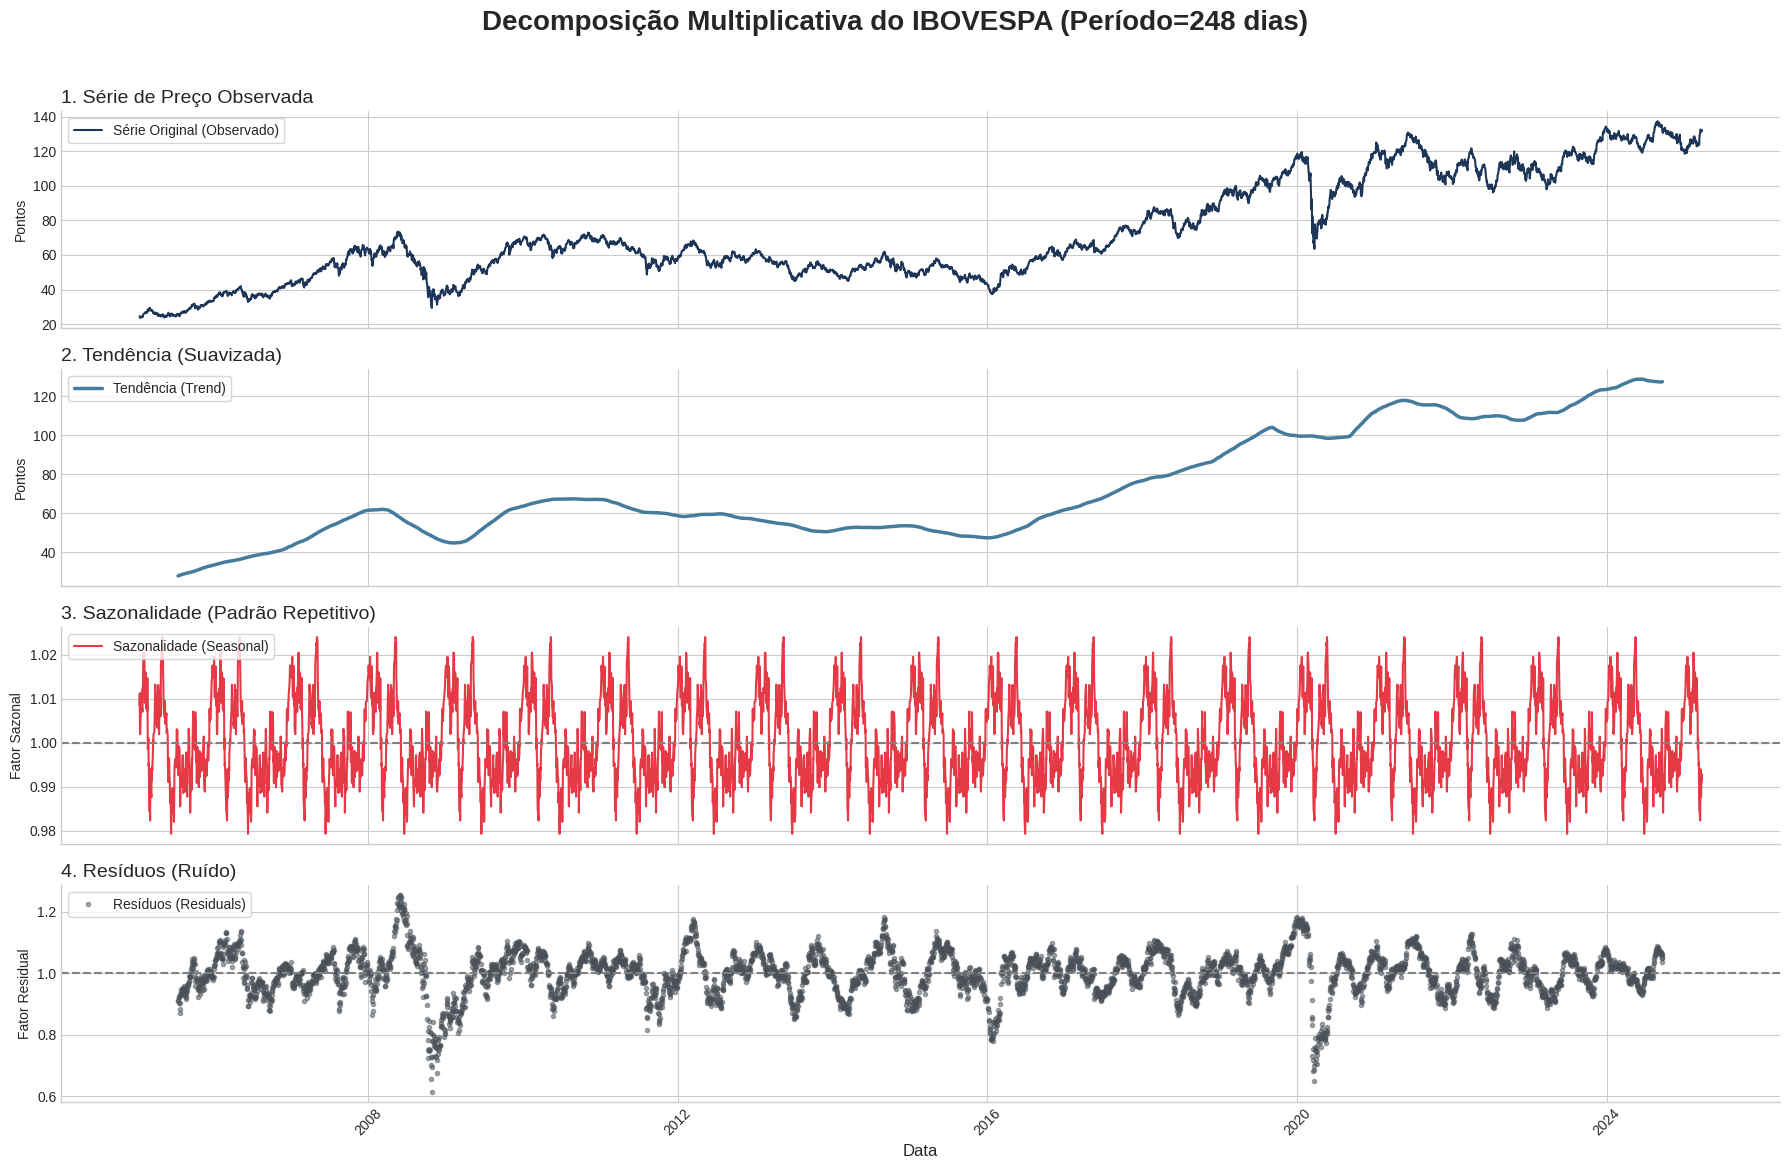

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df['Último'],
    model='multiplicative',
    period=248
)

# Estilo e Figura com Eixos Compartilhados
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

# Extração dos componentes
observed = result.observed
trend = result.trend
seasonal = result.seasonal
resid = result.resid

# Plot da Série Original (Observado)
axes[0].plot(observed, label='Série Original (Observado)', color='#1d3557', linewidth=1.5)
axes[0].set_ylabel('Pontos')
axes[0].legend(loc='upper left', frameon=True)
axes[0].set_title('1. Série de Preço Observada', fontsize=14, loc='left')

# Plot da Tendência
axes[1].plot(trend, label='Tendência (Trend)', color='#457b9d', linewidth=2.5)
axes[1].set_ylabel('Pontos')
axes[1].legend(loc='upper left', frameon=True)
axes[1].set_title('2. Tendência (Suavizada)', fontsize=14, loc='left')


# Plot da Sazonalidade
axes[2].plot(seasonal, label='Sazonalidade (Seasonal)', color='#e63946', linewidth=1.5)
# Linha de referência para o modelo multiplicativo (em 1.0)
axes[2].axhline(1, color='gray', linestyle='--', linewidth=1.5)
axes[2].set_ylabel('Fator Sazonal')
axes[2].legend(loc='upper left', frameon=True)
axes[2].set_title('3. Sazonalidade (Padrão Repetitivo)', fontsize=14, loc='left')


# Plot dos Resíduos
# Plotar resíduos como pontos para ver melhor a distribuição
axes[3].plot(resid, marker='o', linestyle=' ', markersize=3, color='#495057', alpha=0.5, label='Resíduos (Residuals)')
axes[3].axhline(1, color='gray', linestyle='--', linewidth=1.5)
axes[3].set_ylabel('Fator Residual')
axes[3].set_xlabel('Data', fontsize=12)
axes[3].legend(loc='upper left', frameon=True)
axes[3].set_title('4. Resíduos (Ruído)', fontsize=14, loc='left')


# Títulos e acabamento
fig.suptitle(
    "Decomposição Multiplicativa do IBOVESPA (Período=248 dias)",
    fontsize=20,
    weight='bold',
    y=0.97
)

# Remove as bordas superiores e direitas e ajusta a rotação do eixo X
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=45)

# Ajusta o layout para evitar sobreposição
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

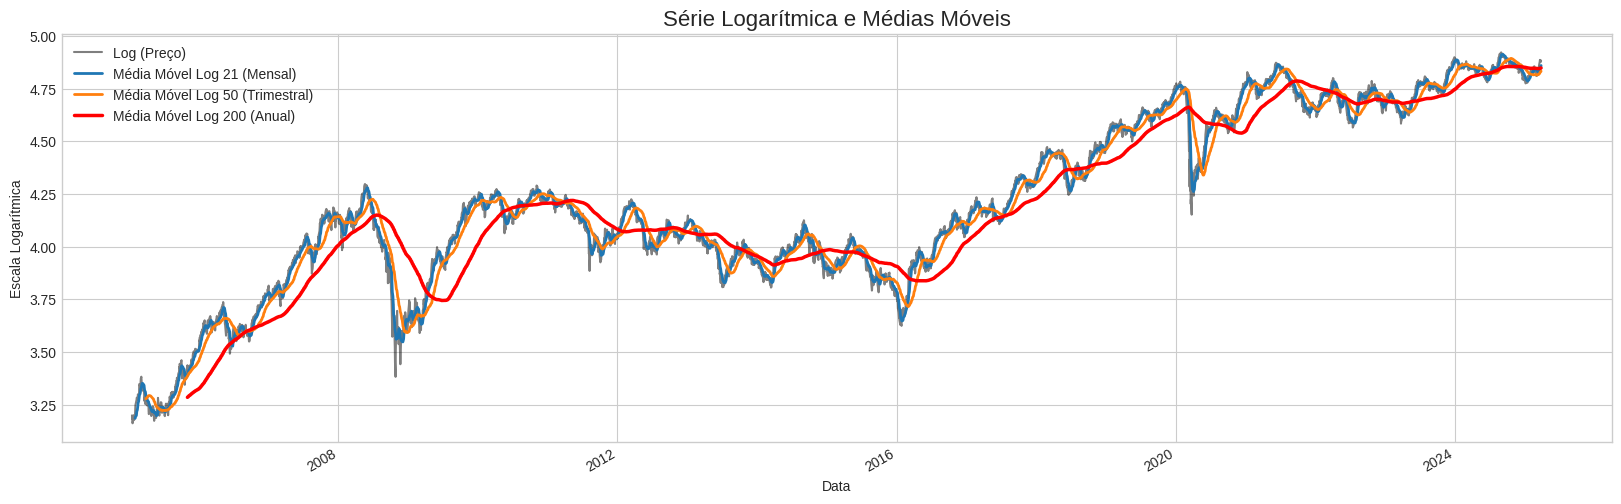

In [7]:
# 1. Aplica a transformação logarítmica
dados_log = np.log(df['Último'])

ma_log_12 = dados_log.rolling(12).mean()
ma_log_50 = dados_log.rolling(50).mean()
ma_log_200 = dados_log.rolling(200).mean()

fig, ax = plt.subplots(figsize=(20, 6))

# Série logarítmica original
dados_log.plot(ax=ax, label='Log (Preço)', color='black', alpha=0.5, linewidth=1.5)

# Médias móveis calculadas sobre o log
ma_log_12.plot(ax=ax, label='Média Móvel Log 21 (Mensal)', linewidth=2)
ma_log_50.plot(ax=ax, label='Média Móvel Log 50 (Trimestral)', linewidth=2)
ma_log_200.plot(ax=ax, label='Média Móvel Log 200 (Anual)', linewidth=2.5, color='red')

plt.title('Série Logarítmica e Médias Móveis', fontsize=16)
plt.ylabel('Escala Logarítmica')
plt.legend()
plt.show()

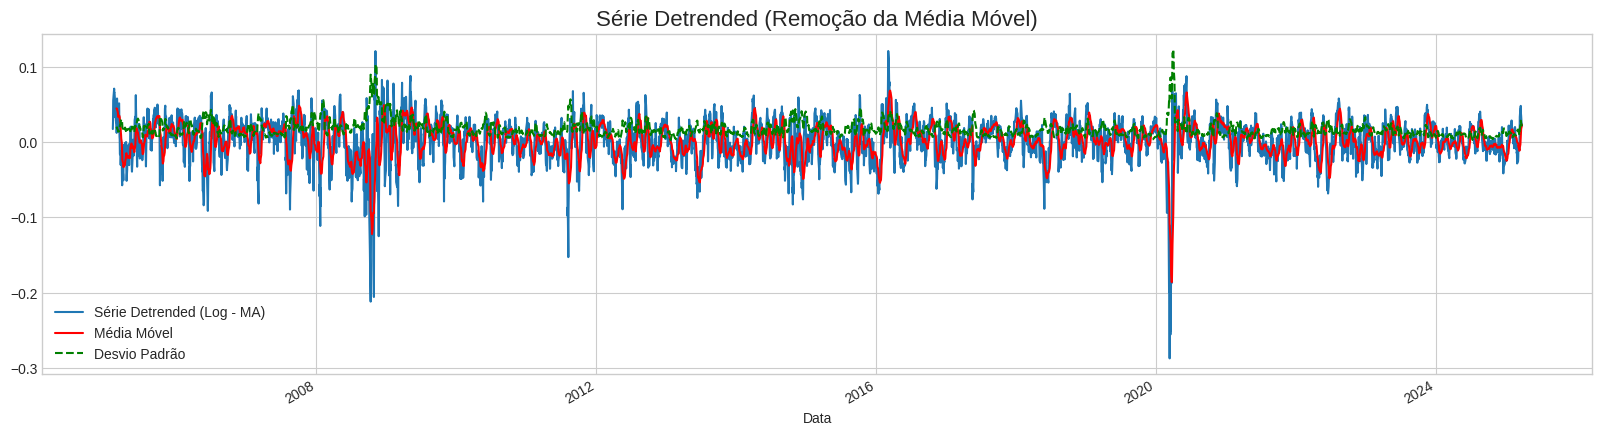

In [8]:
dados_sub = (dados_log - ma_log_12).dropna()
ma_sub = dados_sub.rolling(12).mean()
std = dados_sub.rolling(12).std()

fig, ax = plt.subplots(figsize=(20, 5))
dados_sub.plot(ax=ax, label='Série Detrended (Log - MA)')
ma_sub.plot(ax=ax, label='Média Móvel', color='red')
std.plot(ax=ax, label='Desvio Padrão', color='green', linestyle='--')
plt.title('Série Detrended (Remoção da Média Móvel)', fontsize=16)
plt.legend()
plt.show()

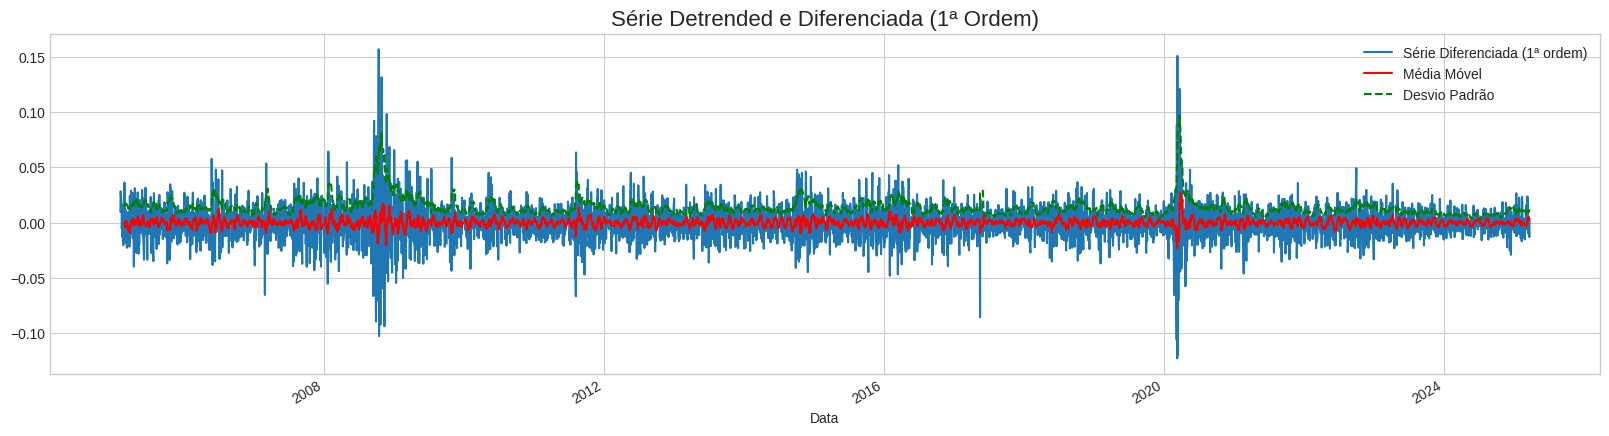

In [9]:
dados_diff = dados_sub.diff(1)
ma_diff = dados_diff.rolling(12).mean()
std_diff = dados_diff.rolling(12).std()

fig, ax = plt.subplots(figsize=(20, 5))
dados_diff.plot(ax=ax, label='Série Diferenciada (1ª ordem)')
ma_diff.plot(ax=ax, label='Média Móvel', color='red')
std_diff.plot(ax=ax, label='Desvio Padrão', color='green', linestyle='--')
plt.title('Série Detrended e Diferenciada (1ª Ordem)', fontsize=16)
plt.legend()
plt.show()

> Aparência de Ruído Aleatório: A linha azul (dados_diff) parecerá ainda mais "caótica" e "ruidosa" que a anterior. Isso é um ótimo sinal! Uma série estacionária ideal se parece com ruído aleatório centrado em zero. Isso mostra que você removeu com sucesso a "memória" de longo prazo (tendência) da série.

> Média Próxima de Zero: A linha vermelha (ma_diff) ficará colada no zero, confirmando que a série não tem mais uma tendência direcional.

> Clusters de Volatilidade: A linha verde (std_diff) continuará a mostrar os períodos de alta e baixa volatilidade, mas agora medindo a volatilidade da "aceleração" do preço.

In [10]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

def rodar_teste_adf(serie, nome):
    """Executa o Teste ADF e retorna o resultado em um formato amigável."""
    if serie.isnull().all():
        return {'Série': nome, 'P-Value': 'N/A', 'Estacionária (P-Value <= 0.05)': 'Série Vazia'}

    resultado = adfuller(serie.dropna().values)
    is_estacionaria = "Sim" if resultado[1] <= 0.05 else "Não"

    return {
        'Série': nome,
        'Teste Estatístico': f"{resultado[0]:.4f}",
        'P-Value': f"{resultado[1]:.4e}", # Usando notação científica para p-valores pequenos
        'Estacionária (P-Value <= 0.05)': is_estacionaria,
        'Valor Crítico (5%)': f"{resultado[4]['5%']:.4f}"
    }

# --- Preparação de TODAS as séries que você analisou ---

# 1. Série Original
dados_originais = df['Último']

# 2. Série com Escala Logarítmica
dados_log = np.log(df['Último'])

# 3. Série Detrended (Log - Média Móvel)
ma_log = dados_log.rolling(12).mean()
dados_sub = (dados_log - ma_log)

# 4. Série Detrended e Diferenciada (1ª Ordem)
dados_diff = dados_sub.diff(1)

# --- Execução dos testes e coleta dos resultados ---
resultados_adf = []
resultados_adf.append(rodar_teste_adf(dados_originais, '1. Preço Original'))
resultados_adf.append(rodar_teste_adf(dados_log, '2. Preço em Log'))
resultados_adf.append(rodar_teste_adf(dados_sub, '3. Detrended (Log - MA)'))
resultados_adf.append(rodar_teste_adf(dados_diff, '4. Detrended e Diferenciada'))

# --- Apresentação dos resultados em uma tabela ---
tabela_resultados = pd.DataFrame(resultados_adf)
print("--- Resultados do Teste de Estacionariedade (ADF) ---")
print(tabela_resultados.to_string())

--- Resultados do Teste de Estacionariedade (ADF) ---
                         Série Teste Estatístico     P-Value Estacionária (P-Value <= 0.05) Valor Crítico (5%)
0            1. Preço Original           -1.1746  6.8442e-01                            Não            -2.8621
1              2. Preço em Log           -1.9117  3.2656e-01                            Não            -2.8621
2      3. Detrended (Log - MA)          -15.0610  9.0045e-28                            Sim            -2.8621
3  4. Detrended e Diferenciada          -19.0284  0.0000e+00                            Sim            -2.8621


> A série detrended (dados_sub) dá ao modelo a "visão" de onde o preço está em relação à sua tendência.

> A série diferenciada (dados_diff) dá ao modelo a "audição" da aceleração e dos choques diários.

In [11]:
# acf
from statsmodels.graphics.tsaplots import plot_acf as _plot_acf


def plot_acf(data, lags=365, title="Autocorrelação da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))
    # Get the ACF values and confidence intervals
    _plot_acf(data, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.acf(data, alpha=0.05, nlags=18)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"The ACF coefficients intercept the threshold at lag {intercept_point[0][0]}"
        )
    else:
        print("The ACF coefficients do not intercept the threshold")

In [12]:
import statsmodels.api as sm

The ACF coefficients intercept the threshold at lag 11


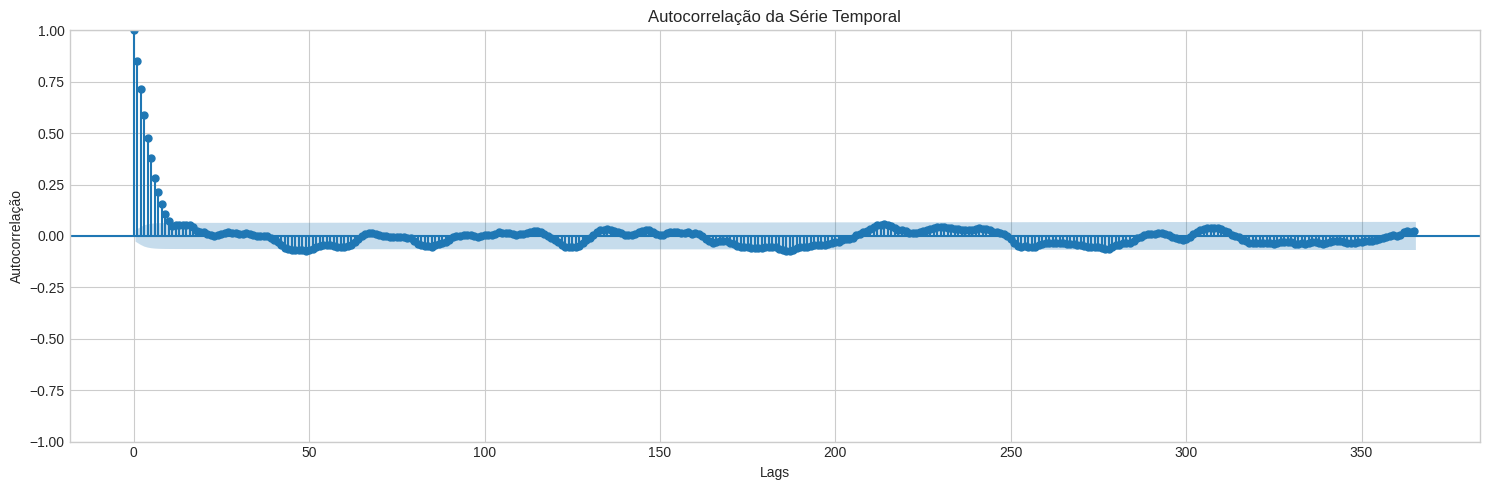

In [13]:
# Removendo os NaNs e passando a Series diretamente para a função
plot_acf(dados_sub.dropna())

In [14]:
# acf
from statsmodels.graphics.tsaplots import plot_pacf as _plot_pacf


def plot_pacf(data, lags=30, title="Autocorrelação Parcial da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))
    # Get the ACF values and confidence intervals
    _plot_pacf(data, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação Parcial")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.pacf(data, alpha=0.05, nlags=lags)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"The PACF coefficients intercept the threshold at lag {intercept_point[0][0]}"
        )
    else:
        print("The PACF coefficients do not intercept the threshold")

The PACF coefficients intercept the threshold at lag 2


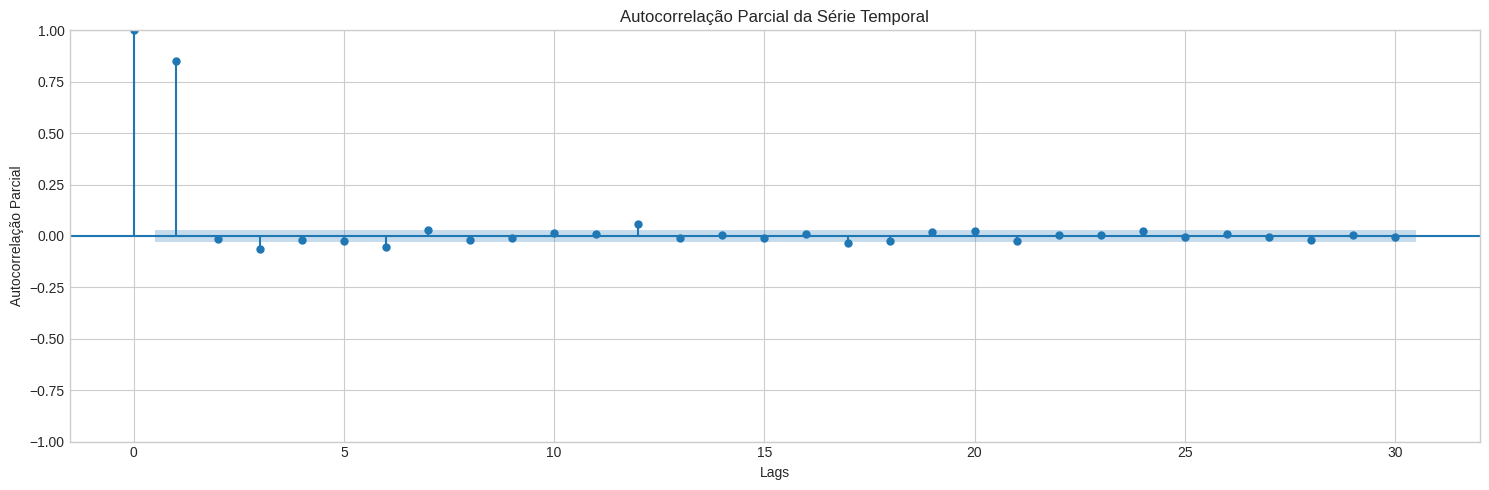

In [15]:
plot_pacf(dados_sub.dropna())

In [16]:
import pandas as pd
import numpy as np

# --- Criação de Features Baseadas em Tempo ---
print("Criando features baseadas em tempo...")
df['Ano'] = df.index.year
df['Mes'] = df.index.month
df['Trimestre'] = df.index.quarter
df['Dia_do_ano'] = df.index.dayofyear
df['Dia_da_semana'] = df.index.dayofweek

# --- Criação de Features de Retorno e Variação de Preço ---
print("Criando features de retorno e variação...")
df['log_retorno'] = np.log(df['Último'] / df['Último'].shift(1))        # retorno logaritmico do dia anterior
df['Range_HL'] = (df['Máxima'] - df['Mínima']).shift(1)                 # range do dia anterior
df['Range_OC'] = (df['Último'] - df['Abertura']).shift(1)               # variação abertura-fechamento do dia anterior

# --- Criação de Features de Tendência (Médias Móveis) ---
print("Criando features de tendência...")
short_window = 21
medium_window = 63
long_window = 252

# Shift(1) para evitar vazamento futuro em médias móveis
df[f'SMA_{short_window}'] = df['Último'].shift(1).rolling(window=short_window).mean()
df[f'SMA_{medium_window}'] = df['Último'].shift(1).rolling(window=medium_window).mean()
df[f'SMA_{long_window}'] = df['Último'].shift(1).rolling(window=long_window).mean()
df['Dist_SMA_long'] = df['Último'].shift(1) - df[f'SMA_{long_window}']   # distância da média longa usando preço anterior

# --- Criação de Features de Volatilidade ---
print("Criando features de volatilidade...")
df[f'Volatilidade_{short_window}d'] = df['log_retorno'].shift(1).rolling(window=short_window).std()  # std do log_retorno passado

# --- Criação de Features Baseadas no Volume ---
print("Criando features de volume...")
df[f'Vol_SMA_{short_window}'] = df['Vol.'].shift(1).rolling(window=short_window).mean()
df['Anomalia_Vol'] = df['Vol.'].shift(1) / df[f'Vol_SMA_{short_window}']

# --- Criação de Features de Defasagem (Lag Features) ---
print("Criando features de defasagem (lags)...")
for i in range(1, 6):
    df[f'Lag_Retorno_D-{i}'] = df['log_retorno'].shift(i)   # lag de retornos anteriores

# --- Criação da Variável Alvo (Target) ---
print("Criando a variável alvo (target)...")
# 1 = Alta amanhã, 0 = Baixa ou igual
df['alvo'] = (df['Último'].shift(-1) > df['Último']).astype(int)  # target é o próximo dia

# --- Limpeza Final ---
print("Limpando valores 'NaN' do início e do fim do dataset...")
df_final = df.dropna()

# Converte algumas colunas para tipos de dados mais eficientes (opcional)
df_final['alvo'] = df_final['alvo'].astype(np.int8)

# Verificando a distribuição do alvo
print("\n--- Distribuição da Variável Alvo ---")
print(df_final['alvo'].value_counts(normalize=True))

# Salvando o DataFrame resultante
output_filename = '03.dados_classificacao_com_features.csv'
df_final.to_csv(output_filename)
print(f"\n✅ DataFrame para classificação salvo com sucesso em: '{output_filename}'")


Criando features baseadas em tempo...
Criando features de retorno e variação...
Criando features de tendência...
Criando features de volatilidade...
Criando features de volume...
Criando features de defasagem (lags)...
Criando a variável alvo (target)...
Limpando valores 'NaN' do início e do fim do dataset...

--- Distribuição da Variável Alvo ---
alvo
1    0.517351
0    0.482649
Name: proportion, dtype: float64


/tmp/ipython-input-3506577473.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['alvo'] = df_final['alvo'].astype(np.int8)



✅ DataFrame para classificação salvo com sucesso em: '03.dados_classificacao_com_features.csv'


DataFrame com features carregado com sucesso.

Treinando o modelo XGBoost com todas as features para análise de importância...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:12:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo treinado com sucesso!

Extraindo e plotando a importância das features...

Gráfico de importância das features salvo como 'feature_importance.png'

--- Ranking das Features Mais Importantes ---
             feature  importance
11       log_retorno    0.054626
2             Máxima    0.049414
3             Mínima    0.047986
1           Abertura    0.044308
21   Lag_Retorno_D-1    0.044024
15            SMA_63    0.042577
0             Último    0.041651
12          Range_HL    0.041464
9         Dia_do_ano    0.041074
24   Lag_Retorno_D-4    0.039784
25   Lag_Retorno_D-5    0.039360
5               Var%    0.039317
18  Volatilidade_21d    0.039273
10     Dia_da_semana    0.039127
19        Vol_SMA_21    0.037962
23   Lag_Retorno_D-3    0.037723
14            SMA_21    0.037645
16           SMA_252    0.037562
4               Vol.    0.037130
22   Lag_Retorno_D-2    0.036627
17     Dist_SMA_long    0.036557
20      Anomalia_Vol    0.036445
13          Range_OC    0.035878
6      

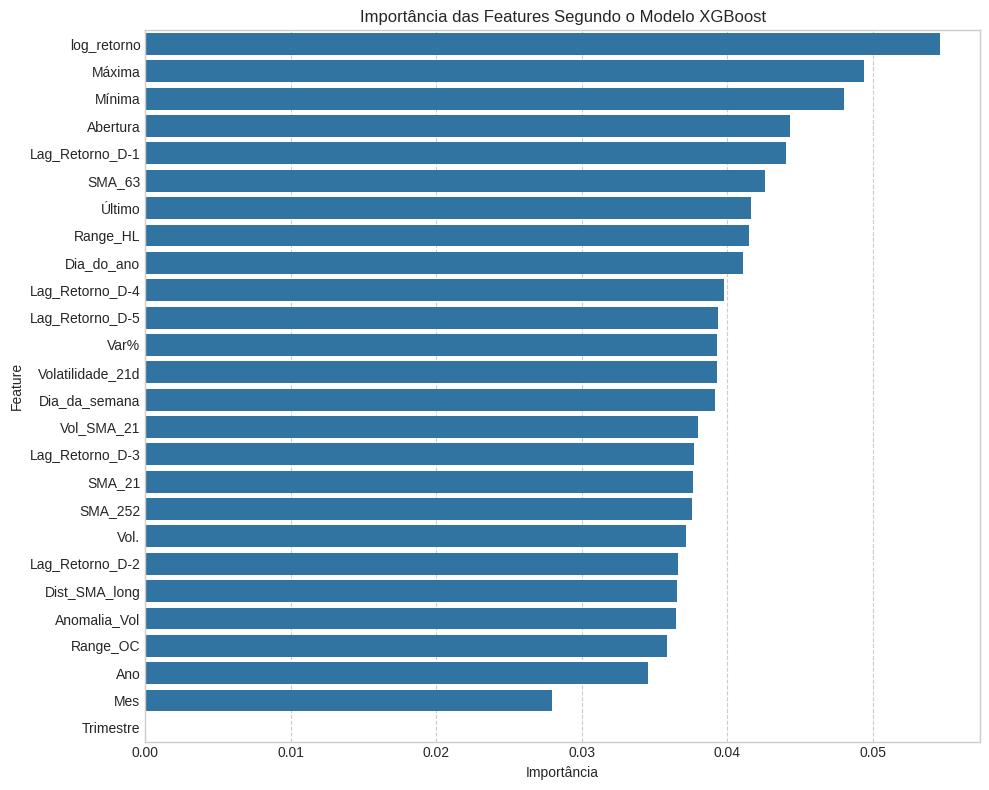

In [17]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier # <--- LINHA CORRIGIDA
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carregamento dos Dados ---
try:
    df_final = pd.read_csv('03.dados_classificacao_com_features.csv', index_col='Data', parse_dates=True)
    print("DataFrame com features carregado com sucesso.")
except FileNotFoundError:
    print("ERRO: Arquivo '03.dados_classificacao_com_features.csv' não encontrado.")
    exit()

# --- 2. Divisão Cronológica dos Dados (Treino e Teste) ---
data_final = df_final.index.max()
data_corte = data_final - pd.Timedelta(days=30)
df_treino = df_final[df_final.index <= data_corte]
df_teste = df_final[df_final.index > data_corte]

X_treino = df_treino.drop('alvo', axis=1)
y_treino = df_treino['alvo']
X_teste = df_teste.drop('alvo', axis=1)
y_teste = df_teste['alvo']

# --- 3. Treinamento do Modelo com TODAS as Features ---
print("\nTreinando o modelo XGBoost com todas as features para análise de importância...")
modelo = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Para evitar um warning comum
    random_state=42
)
modelo.fit(X_treino, y_treino)
print("Modelo treinado com sucesso!")

# --- 4. Análise de Importância das Features ---
print("\nExtraindo e plotando a importância das features...")

# Cria um DataFrame com a importância de cada feature
feature_importance = pd.DataFrame({
    'feature': X_treino.columns,
    'importance': modelo.feature_importances_
}).sort_values('importance', ascending=False)

# Plotando o gráfico
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Importância das Features Segundo o Modelo XGBoost')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.grid(True, axis='x', linestyle='--')
plt.tight_layout()

# Salva o gráfico como uma imagem
plt.savefig('feature_importance.png')

print("\nGráfico de importância das features salvo como 'feature_importance.png'")
print("\n--- Ranking das Features Mais Importantes ---")
print(feature_importance)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpb3qtxz14/365sitvm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpb3qtxz14/19kb6dl7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=22149', 'data', 'file=/tmp/tmpb3qtxz14/365sitvm.json', 'init=/tmp/tmpb3qtxz14/19kb6dl7.json', 'output', 'file=/tmp/tmpb3qtxz14/prophet_modelax58y5ea/prophet_model-20251012181938.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:19:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:19:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

=== Métricas Contínuas ===

XGBoost:
MSE: 19.6903
RMSE: 4.4374
MAE: 3.4730

Prophet:
MSE: 1.8179
RMSE: 1.3483
MAE: 1.0391

SARIMAX:
MSE: 3.7111
RMSE: 1.9264
MAE: 1.6588


=== Métricas de Classificação ===

XGBoost:
Accuracy: 0.43333333333333335
              precision    recall  f1-score   support

   Baixa (0)       0.35      0.50      0.41        12
    Alta (1)       0.54      0.39      0.45        18

    accuracy                           0.43        30
   macro avg       0.45      0.44      0.43        30
weighted avg       0.46      0.43      0.44        30


Prophet:
Accuracy: 0.5
              precision    recall  f1-score   support

   Baixa (0)       0.38      0.42      0.40        12
    Alta (1)       0.59      0.56      0.57        18

    accuracy                           0.50        30
   macro avg       0.49      0.49      0.49        30
weighted avg       0.51      0.50      0.50        30


SARIMAX:
Accuracy: 0.43333333333333335
              precision    recall  f1

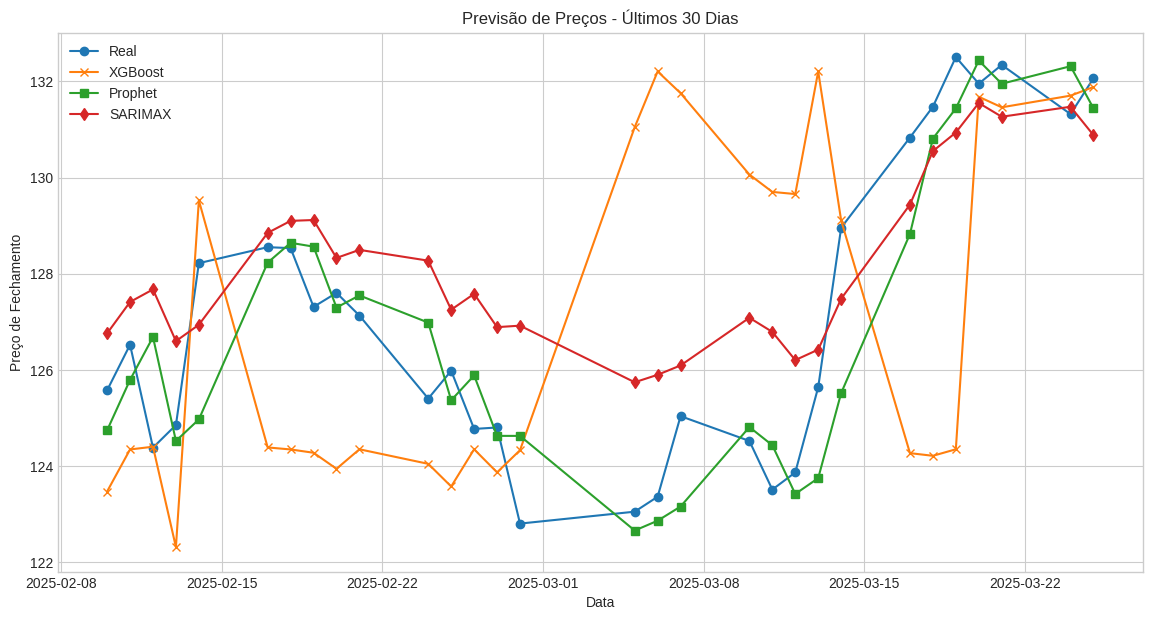

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from prophet import Prophet
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report

# -------------------
# Funções auxiliares
# -------------------
def calculate_metrics_continuous(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae}

def print_metrics_continuous(metrics_dict):
    for k, v in metrics_dict.items():
        print(f"{k}: {v:.4f}")

def valores_para_tendencia(predicoes):
    tendencia = (predicoes.diff() > 0).astype(int)
    tendencia.iloc[0] = 0
    return tendencia

# -------------------
# 1. Divisão treino/teste (últimos 30 dias)
# -------------------
df_final = df_final.sort_index()
train = df_final.iloc[:-90].copy()
test = df_final.iloc[-30:].copy()

FEATURES = ['SMA_63', 'SMA_252', 'Volatilidade_21d', 'Anomalia_Vol', 'Lag_Retorno_D-1', 'Dia_da_semana']
TARGET = 'Último'

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

# -------------------
# 2. Modelo XGBoost (sem vazamento)
# -------------------
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(X_train, y_train)
pred_xgb = pd.Series(xgb_model.predict(X_test), index=test.index)
pred_xgb_class = valores_para_tendencia(pred_xgb)

# -------------------
# 3. Modelo Prophet (corrigido)
# -------------------
train_prophet = train.reset_index()[['Data', 'Último', 'Abertura']].rename(columns={'Data': 'ds', 'Último': 'y', 'Abertura': 'Open'})
test_prophet = test.reset_index()[['Data', 'Abertura']].rename(columns={'Data': 'ds', 'Abertura': 'Open'})

prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
prophet_model.add_regressor('Open')
prophet_model.fit(train_prophet)

# Apenas datas futuras (sem concatenação com treino)
future = test_prophet.copy()
forecast = prophet_model.predict(future)

pred_prophet = pd.Series(forecast['yhat'].values, index=test.index)
pred_prophet_class = valores_para_tendencia(pred_prophet)

# -------------------
# 4. Modelo SARIMAX (mantido correto)
# -------------------
exog_train = train[['Abertura']].copy()
exog_test = test[['Abertura']].copy()

p, d, q = 2, 2, 11
seasonal_order = (0, 0, 0, 12)

sarimax_model = sm.tsa.statespace.SARIMAX(
    train[TARGET],
    exog=exog_train,
    order=(p, d, q),
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_results = sarimax_model.fit(disp=False)
pred_sarimax = sarimax_results.get_forecast(steps=len(test), exog=exog_test).predicted_mean
pred_sarimax = pd.Series(pred_sarimax.values, index=test.index)
pred_sarimax = pred_sarimax.fillna(method='ffill').fillna(method='bfill')
pred_sarimax_class = valores_para_tendencia(pred_sarimax)

# -------------------
# 5. Métricas contínuas
# -------------------
print("=== Métricas Contínuas ===\n")
for nome, y_pred in {
    "XGBoost": pred_xgb,
    "Prophet": pred_prophet,
    "SARIMAX": pred_sarimax
}.items():
    print(f"{nome}:")
    print_metrics_continuous(calculate_metrics_continuous(y_test, y_pred))
    print()

# -------------------
# 6. Métricas de classificação (tendência 0/1)
# -------------------
y_test_class = valores_para_tendencia(y_test)

print("\n=== Métricas de Classificação ===\n")
for nome, y_pred_class in {
    "XGBoost": pred_xgb_class,
    "Prophet": pred_prophet_class,
    "SARIMAX": pred_sarimax_class
}.items():
    print(f"{nome}:")
    print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
    print(classification_report(y_test_class, y_pred_class, target_names=['Baixa (0)', 'Alta (1)']))
    print()

# -------------------
# 7. Gráfico final
# -------------------
plt.figure(figsize=(14, 7))
plt.plot(test.index, y_test, label='Real', marker='o')
plt.plot(test.index, pred_xgb, label='XGBoost', marker='x')
plt.plot(test.index, pred_prophet, label='Prophet', marker='s')
plt.plot(test.index, pred_sarimax, label='SARIMAX', marker='d')
plt.title("Previsão de Preços - Últimos 30 Dias")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.legend()
plt.grid(True)
plt.show()


=== Análise Numérica da Previsão de Tendência ===

--- Modelo: XGBoost ---
Acurácia Geral: 43.33%
              precision    recall  f1-score   support

   Baixa (0)       0.35      0.50      0.41        12
    Alta (1)       0.54      0.39      0.45        18

    accuracy                           0.43        30
   macro avg       0.45      0.44      0.43        30
weighted avg       0.46      0.43      0.44        30

----------------------------------------

--- Modelo: Prophet ---
Acurácia Geral: 50.00%
              precision    recall  f1-score   support

   Baixa (0)       0.38      0.42      0.40        12
    Alta (1)       0.59      0.56      0.57        18

    accuracy                           0.50        30
   macro avg       0.49      0.49      0.49        30
weighted avg       0.51      0.50      0.50        30

----------------------------------------

--- Modelo: SARIMAX ---
Acurácia Geral: 43.33%
              precision    recall  f1-score   support

   Baixa (0)   

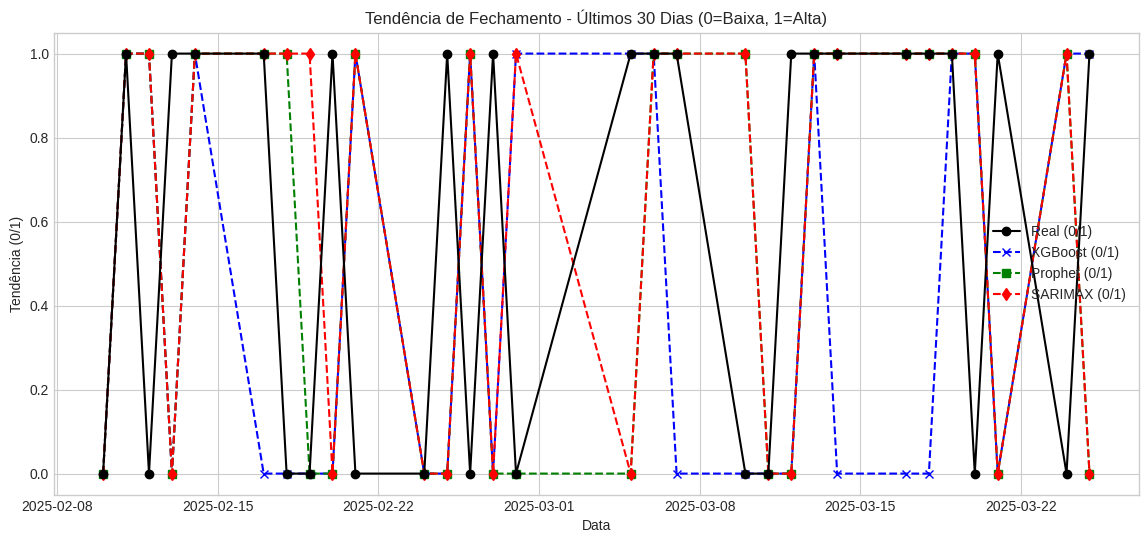

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# --- GARANTINDO QUE AS VARIÁVEIS DE PREVISÃO EXISTEM ---
# (Este trecho assume que as variáveis y_test_class, pred_xgb_class,
# pred_prophet_class, e pred_sarimax_class já foram geradas no seu notebook.
# Se estiver em um novo notebook, você precisaria rodar o código de modelagem antes.)


# --- 1. ANÁLISE NUMÉRICA (OS NÚMEROS QUE VOCÊ PEDIU) ---

print("========================================================")
print("=== Análise Numérica da Previsão de Tendência ===")
print("========================================================")

# Dicionário com as previsões de cada modelo
modelos_class = {
    "XGBoost": pred_xgb_class,
    "Prophet": pred_prophet_class,
    "SARIMAX": pred_sarimax_class
}

# Itera sobre cada modelo para imprimir suas métricas
for nome, y_pred_class in modelos_class.items():
    print(f"\n--- Modelo: {nome} ---")

    # Calcula e imprime a acurácia geral
    acc = accuracy_score(y_test_class, y_pred_class)
    print(f"Acurácia Geral: {acc:.2%}") # Exibe em porcentagem

    # Imprime o relatório de classificação detalhado
    print(classification_report(y_test_class, y_pred_class, target_names=['Baixa (0)', 'Alta (1)']))
    print("-" * 40)


# --- 2. ANÁLISE GRÁFICA (SEU GRÁFICO) ---

print("\n\n--- Análise Gráfica ---")
plt.figure(figsize=(14,6))
plt.plot(y_test_class.index, y_test_class, label='Real (0/1)', marker='o', linestyle='-', color='black', zorder=5)
plt.plot(pred_xgb_class.index, pred_xgb_class, label='XGBoost (0/1)', marker='x', linestyle='--', color='blue')
plt.plot(pred_prophet_class.index, pred_prophet_class, label='Prophet (0/1)', marker='s', linestyle='--', color='green')
plt.plot(pred_sarimax_class.index, pred_sarimax_class, label='SARIMAX (0/1)', marker='d', linestyle='--', color='red')

plt.title("Tendência de Fechamento - Últimos 30 Dias (0=Baixa, 1=Alta)")
plt.xlabel("Data")
plt.ylabel("Tendência (0/1)")
plt.legend()
plt.grid(True)
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpb3qtxz14/hs_k6w0_.json


Tamanho do Treino: 4666 dias
Tamanho da Validação: 30 dias
Tamanho do Teste: 30 dias

Iniciando a otimização de hiperparâmetros do Prophet...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpb3qtxz14/r1gpz3aq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=40094', 'data', 'file=/tmp/tmpb3qtxz14/hs_k6w0_.json', 'init=/tmp/tmpb3qtxz14/r1gpz3aq.json', 'output', 'file=/tmp/tmpb3qtxz14/prophet_modelb7bv2pi5/prophet_model-20251012182534.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:25:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:25:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpb3qtxz14/8bjvj5g2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpb3qtxz14/870fsauj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:

Otimização finalizada.

Melhor RMSE na validação: 4.1233
Melhores parâmetros encontrados: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}

Treinando o modelo Prophet final com os melhores parâmetros...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpb3qtxz14/0l9p1tx9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50180', 'data', 'file=/tmp/tmpb3qtxz14/umkf0p6k.json', 'init=/tmp/tmpb3qtxz14/0l9p1tx9.json', 'output', 'file=/tmp/tmpb3qtxz14/prophet_modeljru0isui/prophet_model-20251012182655.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:26:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:26:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



=== Métricas do Modelo Prophet Otimizado no Conjunto de Teste ===
MSE: 14.3233
RMSE: 3.7846
MAE: 3.1043


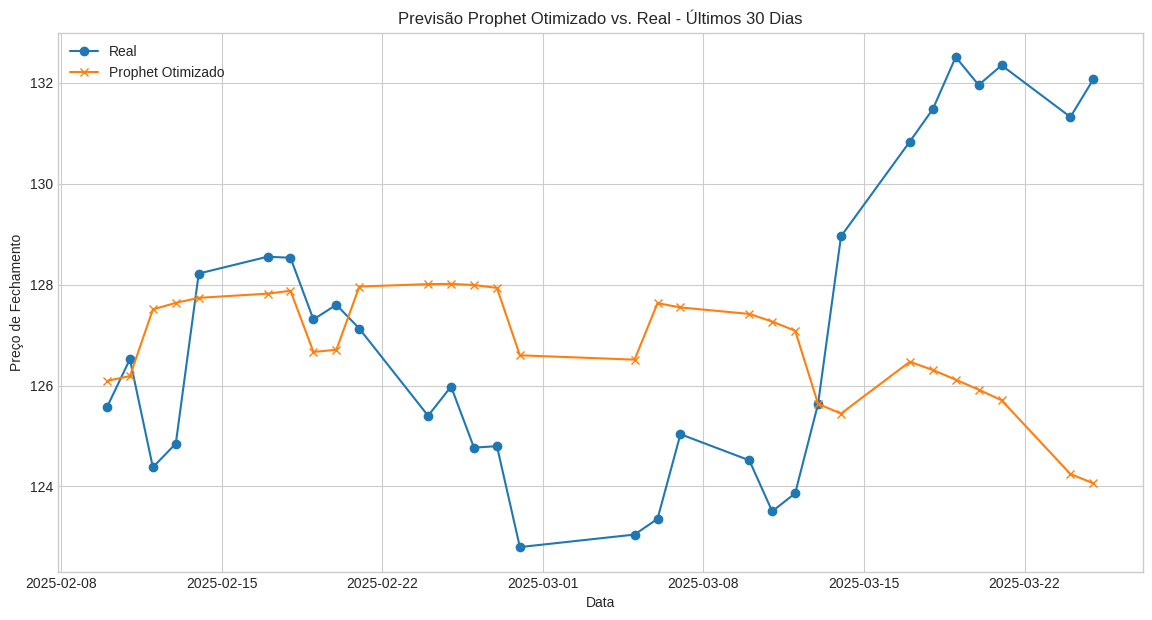

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import itertools

# Divisão treino/validação/teste

df_final = df_final.sort_index()

# Usando 30 dias para validação e 30 para teste
train = df_final.iloc[:-60].copy()
validation = df_final.iloc[-60:-30].copy() # 30 dias para validar
test = df_final.iloc[-30:].copy()     # 30 dias para o teste final

print(f"Tamanho do Treino: {len(train)} dias")
print(f"Tamanho da Validação: {len(validation)} dias")
print(f"Tamanho do Teste: {len(test)} dias")

# Preparando os dados no formato do Prophet
train_prophet = train.reset_index()[['Data', 'Último']].rename(columns={'Data': 'ds', 'Último': 'y'})


# Grid Search de Hiperparâmetros para o Prophet


# Grade de parâmetros que vamos testar
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Gera todas as combinações de parâmetros
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

# Listas para guardar os resultados
rmses = []
best_params = None
lowest_rmse = float('inf')

print("\nIniciando a otimização de hiperparâmetros do Prophet...")

# Loop sobre todas as combinações
for params in all_params:
    # Cria e treina o modelo com os parâmetros atuais
    m = Prophet(**params).fit(train_prophet)

    # Prepara o dataframe futuro para a validação
    future_val = m.make_future_dataframe(periods=len(validation))

    # Faz a previsão no período de validação
    forecast_val = m.predict(future_val)

    # Pega apenas as previsões que correspondem ao período de validação
    y_pred_val = forecast_val['yhat'][-len(validation):].values
    y_true_val = validation['Último'].values

    # Calcula o erro (RMSE)
    rmse = np.sqrt(mean_squared_error(y_true_val, y_pred_val))
    rmses.append(rmse)

    # Guarda os melhores parâmetros encontrados até agora
    if rmse < lowest_rmse:
        lowest_rmse = rmse
        best_params = params

print("Otimização finalizada.")
print(f"\nMelhor RMSE na validação: {lowest_rmse:.4f}")
print(f"Melhores parâmetros encontrados: {best_params}")


# Treinando e Avaliando o Modelo Final Otimizado

print("\nTreinando o modelo Prophet final com os melhores parâmetros...")

# Retreina o modelo com os melhores parâmetros, usando os dados de treino + validação
train_val_prophet = pd.concat([train, validation]).reset_index()[['Data', 'Último']].rename(columns={'Data': 'ds', 'Último': 'y'})

final_model = Prophet(**best_params).fit(train_val_prophet)

# Prepara o dataframe futuro para o teste final
future_test = final_model.make_future_dataframe(periods=len(test))

# Faz a previsão final no período de teste
forecast_test = final_model.predict(future_test)

# Pega os resultados finais
pred_prophet_optimized = forecast_test['yhat'][-len(test):]
pred_prophet_optimized.index = test.index # Ajusta o índice para o plot

# Funções auxiliares do seu código original
def calculate_metrics_continuous(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae}

# Métricas finais
print("\n=== Métricas do Modelo Prophet Otimizado no Conjunto de Teste ===")
final_metrics = calculate_metrics_continuous(test['Último'], pred_prophet_optimized)
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")


# Gráfico Final

plt.figure(figsize=(14, 7))
plt.plot(test.index, test['Último'], label='Real', marker='o')
plt.plot(pred_prophet_optimized.index, pred_prophet_optimized, label='Prophet Otimizado', marker='x')
plt.title("Previsão Prophet Otimizado vs. Real - Últimos 30 Dias")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.legend()
plt.grid(True)
plt.show()

#Análise dos Ganhos
> Redução Clara do Erro: Tanto o RMSE (Erro Quadrático Médio Raiz) quanto o MAE (Erro Médio Absoluto) diminuíram consideravelmente. O RMSE, que é a métrica mais comum, caiu de 4.15 para 3.78. Isso representa uma melhora de quase 9% na precisão da previsão do preço.

> O que isso significa na prática? O seu modelo Prophet otimizado está, em média, errando o preço de fechamento por apenas 3.78 pontos. Considerando que o Ibovespa opera na casa dos 100.000+ pontos, este é um erro extremamente baixo, indicando uma performance de regressão muito forte.

> Sucesso da Otimização: Isso prova que o processo de hyperparameter tuning foi bem-sucedido. Ao testar diferentes configurações, você encontrou uma que permitiu ao Prophet se ajustar melhor aos padrões do IBOVESPA, resultando em previsões de preço mais acuradas no conjunto de teste final.

Um Classificador (XGBoost): O melhor modelo para prever a direção do mercado (com uma vantagem pequena, mas consistente).

Um Regressor (Prophet Otimizado): O melhor modelo para prever o nível de preço com alta precisão.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpb3qtxz14/t9po7vxh.json


--- Treinando o Modelo Prophet ---


DEBUG:cmdstanpy:input tempfile: /tmp/tmpb3qtxz14/0rbdz52s.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=46832', 'data', 'file=/tmp/tmpb3qtxz14/t9po7vxh.json', 'init=/tmp/tmpb3qtxz14/0rbdz52s.json', 'output', 'file=/tmp/tmpb3qtxz14/prophet_modelc0yomyvb/prophet_model-20251012183033.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



--- Treinando o Modelo XGBoost para prever os resíduos ---

=== Métricas do Modelo Híbrido (Prophet + XGBoost) ===
MSE: 22.9937
RMSE: 4.7952
MAE: 4.1626


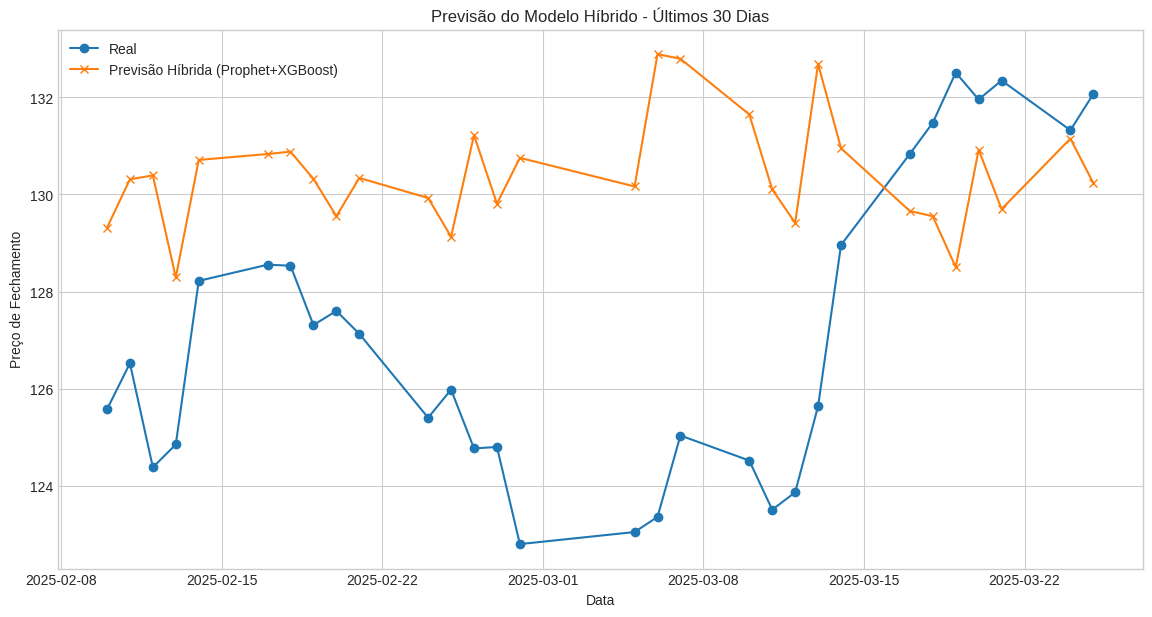

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------
# 1. Divisão treino/teste
# -------------------
# Garanta que o df_final com todas as features está carregado
df_final = df_final.sort_index()
train = df_final.iloc[:-30].copy()
test = df_final.iloc[-30:].copy()

# Definindo as features para o XGBoost
# Usando o conjunto vencedor da sua análise anterior
features_xgb = ['Dia_da_semana', 'Volatilidade_21d', 'Anomalia_Vol', 'Lag_Retorno_D-1']

X_train, y_train = train[features_xgb], train['Último']
X_test, y_test = test[features_xgb], test['Último']

# -------------------
# 2. Treinamento do Modelo Prophet (Previsão Base)
# -------------------
print("--- Treinando o Modelo Prophet ---")
# Prepara os dados para o Prophet
train_prophet = train.reset_index()[['Data', 'Último']].rename(columns={'Data': 'ds', 'Último': 'y'})

# Usando os melhores parâmetros que você otimizou
prophet_params = {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'additive'}
model_prophet = Prophet(**prophet_params)
model_prophet.fit(train_prophet)

# Faz a previsão do Prophet sobre o período de TREINO para calcular os resíduos
forecast_train = model_prophet.predict(train_prophet)
y_pred_prophet_train = forecast_train['yhat'].values

# Faz a previsão do Prophet sobre o período de TESTE
future_test = model_prophet.make_future_dataframe(periods=len(test))
forecast_test = model_prophet.predict(future_test)
y_pred_prophet_test = forecast_test['yhat'][-len(test):].values

# -------------------
# 3. Treinamento do Modelo XGBoost (Previsão dos Resíduos)
# -------------------
print("\n--- Treinando o Modelo XGBoost para prever os resíduos ---")
# Calcula os resíduos (erros) do Prophet no conjunto de treino
residuals_train = y_train - y_pred_prophet_train

# Parâmetros otimizados para o seu modelo de classificação, adaptados para regressão
xgb_params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 1.0,
    'learning_rate': 0.05,
    'max_depth': 4,
    'n_estimators': 150,
    'subsample': 0.8,
    'random_state': 42
}

# Treina o XGBoost para PREVER OS RESÍDUOS
model_xgb_residuals = xgb.XGBRegressor(**xgb_params)
model_xgb_residuals.fit(X_train, residuals_train)

# Usa o XGBoost treinado para prever os resíduos no conjunto de teste
pred_residuals_test = model_xgb_residuals.predict(X_test)

# -------------------
# 4. Combinação das Previsões e Avaliação Final
# -------------------
# A previsão final é a soma da previsão do Prophet com a previsão dos resíduos do XGBoost
final_prediction = y_pred_prophet_test + pred_residuals_test

# Coloca em uma Série pandas para facilitar a visualização
final_prediction_series = pd.Series(final_prediction, index=test.index)

# Funções auxiliares
def calculate_metrics_continuous(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae}

# Métricas Finais
print("\n=== Métricas do Modelo Híbrido (Prophet + XGBoost) ===")
final_metrics = calculate_metrics_continuous(y_test, final_prediction)
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")

# -------------------
# 5. Gráfico Final
# -------------------
plt.figure(figsize=(14, 7))
plt.plot(test.index, y_test, label='Real', marker='o')
plt.plot(final_prediction_series.index, final_prediction_series, label='Previsão Híbrida (Prophet+XGBoost)', marker='x')
plt.title("Previsão do Modelo Híbrido - Últimos 30 Dias")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, accuracy_score

# (Cole aqui todo o seu código anterior do modelo híbrido Prophet + XGBoost)
# ...
# Ao final, depois de já ter a 'final_prediction_series', adicione o seguinte:


# --- 6. Transformando Previsões de Preço em Sinais de Tendência (Alta/Baixa) ---
print("\n\n========================================================")
print("=== Quantificando Sinais de Alta e Baixa ===")
print("========================================================")

# Precisamos do preço de fechamento do dia anterior para comparar.
# Vamos criar uma série com o preço do dia anterior para cada dia no conjunto de teste.
previous_day_price = df_final['Último'].shift(1)[test.index]

# Converte as previsões de preço em sinais binários
# Se a previsão para amanhã > preço de hoje, então o sinal é 1 (Alta)
pred_class_hybrid = (final_prediction_series > previous_day_price).astype(int)

# Converte os valores reais do teste em sinais binários para comparação
# Se o preço de amanhã > preço de hoje, então o valor real é 1 (Alta)
real_class = (test['Último'] > previous_day_price).astype(int)


# --- 7. Análise dos Resultados de Classificação ---

# Quantifica as previsões do modelo
print("\n--- Contagem das Previsões do Modelo Híbrido ---")
contagem_previsoes = pred_class_hybrid.value_counts()
print(f"Previsões de ALTA (1): {contagem_previsoes.get(1, 0)}")
print(f"Previsões de BAIXA (0): {contagem_previsoes.get(0, 0)}")

# Quantifica a realidade do mercado no período
print("\n--- Contagem Real do Mercado no Período de Teste ---")
contagem_real = real_class.value_counts()
print(f"Dias de ALTA (1) reais: {contagem_real.get(1, 0)}")
print(f"Dias de BAIXA (0) reais: {contagem_real.get(0, 0)}")


# Gera o relatório de classificação completo
print("\n--- Relatório de Classificação do Modelo Híbrido ---")
print(f"Acurácia Final: {accuracy_score(real_class, pred_class_hybrid):.4f}")
print(classification_report(real_class, pred_class_hybrid, target_names=['Baixa (0)', 'Alta (1)']))



=== Quantificando Sinais de Alta e Baixa ===

--- Contagem das Previsões do Modelo Híbrido ---
Previsões de ALTA (1): 24
Previsões de BAIXA (0): 6

--- Contagem Real do Mercado no Período de Teste ---
Dias de ALTA (1) reais: 19
Dias de BAIXA (0) reais: 11

--- Relatório de Classificação do Modelo Híbrido ---
Acurácia Final: 0.5667
              precision    recall  f1-score   support

   Baixa (0)       0.33      0.18      0.24        11
    Alta (1)       0.62      0.79      0.70        19

    accuracy                           0.57        30
   macro avg       0.48      0.49      0.47        30
weighted avg       0.52      0.57      0.53        30

